In [1]:
import pandas as pd

rent = pd.read_csv('data/apartments_for_rent_classified_10K.csv', sep=';', encoding='latin1')

rent.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [2]:
pd.set_option('display.max_colwidth', None)
rent[rent['category'] == 'housing/rent/short_term']

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
5531,5641785233,housing/rent/short_term,Apartment sublease $775/mo,"Sublease needed from December/beginning of January to August 15th, 2020, just in time for Spring and Summer semesters. The apartment is a fully furnished two bedrooms and I will likely leave my king size mattress behind if that'd be of use! You'd likely be taking the bigger room of the two. This apartment building is located right on Baseline facing the Flat Irons, right by bus route/public transportation stops and about 30 minutes from Denver. Walking distance from CU Boulder, roommate and I can attest, as well as coffee shops, yoga, and restaurants. Roommate is a junior at CU Boulder, quiet but friendly and super clean female. The apartment is 850 sq-ft and has one shared bathroom thats kept super clean. The utilities are included in rent (heat, water, trash, recycling, sewer). Roommate handles wifi and there is a fullsize washer/dryer area in the building.","Parking,Pool",NaN,2.0,USD,No,Thumbnail,...,$775,Monthly,850,NaN,Boulder,CO,40.0213,-105.2552,ListedBuy,1575602264
6052,5629355898,housing/rent/short_term,Room with private bathroom for rent in a furnished 2 BR 2 BA apartment,"I have a vacant room furnished with a queen bed with foam mattress, study table and dressers for $500/month. The room has a closet and spacious private bathroom. The apartment (900+ sq ft) has a private cloths washer and drier, and parking spot. The rent includes water, Internet and heating except electricity, access to gym, swimming pool and recreation zone. The location is ~ 2mis from campus and there is a bus stop within the apartment complex. I am looking for a responsible, clean and a professional working individual to rent the room. I am a professional engineer, graduated three years ago and recently moved to college station for work. I can be contacted for further enquiries of the room at Listedbuy. com","Gym,Internet Access,Pool,Washer Dryer",2.0,2.0,USD,No,Thumbnail,...,$500,Monthly,900,NaN,Bryan,TX,30.7084,-96.3470,ListedBuy,1575062563


remove short term rent, only 2 rows

In [3]:
rent.dtypes

id                 int64
category          object
title             object
body              object
amenities         object
bathrooms        float64
bedrooms         float64
currency          object
fee               object
has_photo         object
pets_allowed      object
price              int64
price_display     object
price_type        object
square_feet        int64
address           object
cityname          object
state             object
latitude         float64
longitude        float64
source            object
time               int64
dtype: object

In [4]:
rent['category'].unique()

array(['housing/rent/apartment', 'housing/rent/home',
       'housing/rent/short_term'], dtype=object)

rename to apartment and home 

In [5]:
#print unique title in dataframe
unique_titles_df = pd.DataFrame(rent['title'].unique(), columns=['Unique Titles'])

# Display 
unique_titles_df

,Unique Titles
0,"Studio apartment 2nd St NE, Uhland Terrace NE, Washington, DC 20002"
1,Studio apartment 814 Schutte Road
2,"Studio apartment N Scott St, 14th St N, Arlington, VA 22209"
3,Studio apartment 1717 12th Ave
4,"Studio apartment Washington Blvd, N Cleveland St, Arlington"
...,...
9345,Five BR 5407 Abbott Place - Abbott
9346,Six BR 256 Las Entradas
9347,Six BR 9908 Bentcross Drive
9348,One BR in New York NY 10069


In [6]:
rent['body'].unique()

array(['This unit is located at second St NE, Uhland Terrace NE, Washington, DC 20002, Washington, 20002, DCMonthly rental rates range from $790 - $1090We have studio units available for rent',
       'This unit is located at 814 Schutte Road, Evansville, 47712, INMonthly rental rates range from $425 - $445We have studio - 1 beds units available for rent',
       'This unit is located at N Scott St, 14th St N, Arlington, VA 22209, Arlington, 22209, VAMonthly rental rates range from $1390We have studio units available for rent',
       ...,
       'This unit is located at 9908 Bentcross Drive, Potomac, 20854, MDMonthly rental rates range from $11000We have 6 beds units available for rent',
       "Monthly Rent$4,605 -to $4,790AmenitiesThe Aldyn offers some of the finest amenities amongst Upper West Side apartments. The club-style way of apartment living offers residents countless amenities right at their doorstep - the cornerstone being the 40,000 sq. feet La Palestra Athletic Club and 

title and body are redundant 

In [7]:
# 1. Filter out the short_term rows
rent = rent[rent['category'] != 'housing/rent/short_term']

# 2. Drop the unwanted columns
rent = rent.drop(columns=['title', 'body', 'source', 'time', 'price_display'])

# 3. Rename your remaining categories
rent['category'] = rent['category'].replace({
    'housing/rent/apartment': 'apartment',
    'housing/rent/home': 'home'
})

rent.head()

,id,category,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude
0,5668626895,apartment,NaN,NaN,0.0,USD,No,Thumbnail,NaN,790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861
1,5664597177,apartment,NaN,NaN,1.0,USD,No,Thumbnail,NaN,425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621
2,5668626833,apartment,NaN,1.0,0.0,USD,No,Thumbnail,NaN,1390,Monthly,107,NaN,Arlington,VA,38.8910,-77.0816
3,5659918074,apartment,NaN,1.0,0.0,USD,No,Thumbnail,NaN,925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275
4,5668626759,apartment,NaN,NaN,0.0,USD,No,Thumbnail,NaN,880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055


In [8]:
rent['amenities'].unique()

array([nan, 'Dishwasher,Elevator,Patio/Deck,Pool,Storage', 'Refrigerator',
       ...,
       'Cable or Satellite,Dishwasher,Fireplace,Parking,Patio/Deck,Refrigerator,Wood Floors',
       'Elevator,Gym,Parking,Patio/Deck,Pool,Storage,Tennis,View',
       'Basketball,Cable or Satellite,Doorman,Hot Tub,Internet Access,Parking,Playground,Pool,Storage,Washer Dryer'],
      shape=(2255,), dtype=object)

Multi-Hot Encoding (The Best Way)
Since the amenities are comma-separated strings, you should split them and create a "binary" column for each unique amenity. If an apartment has a "Pool," that column gets a 1; otherwise, it gets a 0.

or 

Amenity Count keeps the dataset simple and captures "luxury level."	Loses the specific detail of what the amenities actually are.


While this is the correct approach for classification, be aware that if your dataset has 100 unique amenities, your DataFrame will suddenly grow by 100 new columns.

Tip: If you find you have too many columns after this process, you can filter out rare amenities (those that appear in fewer than, say, 1% of listings) to keep your model efficient.


In your data, many rows have null or nan for amenities. In rental listings, a null usually doesn't mean "missing data"—it usually means the landlord didn't check any boxes, effectively implying "No special amenities." * Recommendation: Treat NaN as a valid category (e.g., "None") rather than deleting those rows.

In [9]:
# 1. Drop NaNs and split every string into a list of words
# 2. .explode() turns those lists into individual rows
# 3. .value_counts() counts the frequency of every unique word
amenity_counts = rent['amenities'].dropna().str.split(',').explode().value_counts()

# Display the results
print(amenity_counts)

amenities
Parking               3726
Dishwasher            3266
Pool                  3236
Refrigerator          3133
Patio/Deck            2472
Cable or Satellite    1678
Storage               1531
Gym                   1468
Internet Access       1440
Clubhouse             1317
Garbage Disposal      1210
Washer Dryer          1076
Fireplace             1065
Playground             782
AC                     662
Elevator               642
Tennis                 482
Gated                  473
Wood Floors            357
Hot Tub                346
Basketball             318
TV                     207
View                   149
Doorman                 29
Alarm                   23
Golf                    23
Luxury                  11
Name: count, dtype: int64


In [10]:
# 1. Fill NaNs first to avoid errors (contains() doesn't like nulls)
rent['amenities'] = rent['amenities'].fillna('')

# 2. Extract rows where 'Luxury' is in the amenities string
# case=False makes it catch 'luxury' or 'Luxury'
luxury_listings = rent[rent['amenities'].str.contains('Luxury', case=False)]

# 3. View the results
luxury_listings

,id,category,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude
642,5668627531,apartment,Luxury,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1688,Monthly,448,NaN,Austin,TX,30.3054,-97.7497
1088,5509272216,apartment,Luxury,1.0,2.0,USD,No,Yes,NaN,1305,Monthly,515,NaN,Baltimore,MD,39.2946,-76.6235
2113,5668625536,apartment,"Cable or Satellite,Dishwasher,Elevator,Fireplace,Garbage Disposal,Internet Access,Luxury,Parking,Patio/Deck,Playground,Refrigerator,Storage",1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",1025,Monthly,616,4320 North Towne Court,Windsor,WI,43.2128,-89.3435
2874,5659899387,apartment,"Dishwasher,Elevator,Luxury,Parking,Patio/Deck,Storage",1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1026,Monthly,669,260 Leigh Farm Rd,Durham,NC,35.9907,-78.9074
4092,5509255794,apartment,Luxury,1.0,1.0,USD,No,No,NaN,2791,Monthly,748,NaN,Pasadena,CA,34.1659,-118.1629
4993,5664576910,apartment,"Cable or Satellite,Dishwasher,Elevator,Garbage Disposal,Internet Access,Luxury,Parking,Patio/Deck,Pool,Refrigerator,View",1.0,3.0,USD,No,Thumbnail,"Cats,Dogs",1365,Monthly,802,822 E Washington,Madison,WI,43.0724,-89.4003
5634,5509117852,apartment,Luxury,1.0,2.0,USD,No,Yes,"Cats,Dogs",1724,Monthly,864,NaN,Kent,WA,47.3907,-122.2626
6622,5668612642,apartment,"Cable or Satellite,Clubhouse,Dishwasher,Garbage Disposal,Internet Access,Luxury,Parking,Patio/Deck,Pool,Refrigerator",1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",1425,Monthly,973,3511 Great Cypress Cir,Ruskin,FL,27.7164,-82.4294
7512,5509058453,apartment,Luxury,1.5,2.0,USD,No,Thumbnail,"Cats,Dogs",990,Monthly,1100,NaN,Raleigh,NC,35.8036,-78.6974
8847,5509202038,apartment,Luxury,2.0,3.0,USD,No,No,NaN,1150,Monthly,1429,NaN,Norman,OK,35.2441,-97.4144


In [11]:
# 1. Ensure price is numeric (it may load as a string if there were symbols)
rent['price'] = pd.to_numeric(rent['price'], errors='coerce')

# 2. Create a helper column to identify Luxury vs Others
# We use case=False to be safe with capitalization
rent['is_luxury'] = rent['amenities'].fillna('').str.contains('Luxury', case=False)

# 3. Calculate the averages
comparison = rent.groupby('is_luxury')['price'].mean()

print("Average Price Comparison:")
print(f"Non-Luxury Listings: ${comparison[False]:,.2f}")
print(f"Luxury Listings:     ${comparison[True]:,.2f}")

# 4. Display the specific 11 luxury rows to inspect them
luxury_listings = rent[rent['is_luxury'] == True]
luxury_listings

Average Price Comparison:
Non-Luxury Listings: $1,486.33
Luxury Listings:     $1,589.45


,id,category,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,is_luxury
642,5668627531,apartment,Luxury,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1688,Monthly,448,NaN,Austin,TX,30.3054,-97.7497,True
1088,5509272216,apartment,Luxury,1.0,2.0,USD,No,Yes,NaN,1305,Monthly,515,NaN,Baltimore,MD,39.2946,-76.6235,True
2113,5668625536,apartment,"Cable or Satellite,Dishwasher,Elevator,Fireplace,Garbage Disposal,Internet Access,Luxury,Parking,Patio/Deck,Playground,Refrigerator,Storage",1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",1025,Monthly,616,4320 North Towne Court,Windsor,WI,43.2128,-89.3435,True
2874,5659899387,apartment,"Dishwasher,Elevator,Luxury,Parking,Patio/Deck,Storage",1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1026,Monthly,669,260 Leigh Farm Rd,Durham,NC,35.9907,-78.9074,True
4092,5509255794,apartment,Luxury,1.0,1.0,USD,No,No,NaN,2791,Monthly,748,NaN,Pasadena,CA,34.1659,-118.1629,True
4993,5664576910,apartment,"Cable or Satellite,Dishwasher,Elevator,Garbage Disposal,Internet Access,Luxury,Parking,Patio/Deck,Pool,Refrigerator,View",1.0,3.0,USD,No,Thumbnail,"Cats,Dogs",1365,Monthly,802,822 E Washington,Madison,WI,43.0724,-89.4003,True
5634,5509117852,apartment,Luxury,1.0,2.0,USD,No,Yes,"Cats,Dogs",1724,Monthly,864,NaN,Kent,WA,47.3907,-122.2626,True
6622,5668612642,apartment,"Cable or Satellite,Clubhouse,Dishwasher,Garbage Disposal,Internet Access,Luxury,Parking,Patio/Deck,Pool,Refrigerator",1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",1425,Monthly,973,3511 Great Cypress Cir,Ruskin,FL,27.7164,-82.4294,True
7512,5509058453,apartment,Luxury,1.5,2.0,USD,No,Thumbnail,"Cats,Dogs",990,Monthly,1100,NaN,Raleigh,NC,35.8036,-78.6974,True
8847,5509202038,apartment,Luxury,2.0,3.0,USD,No,No,NaN,1150,Monthly,1429,NaN,Norman,OK,35.2441,-97.4144,True


Filter Rare Amenities
since there are 10k row in the dataset, you might want to exclude amenities that appear in less than 1% of your data (less than 100 times). This keeps your model lean.

Grouping Similar Features
You could combine rare, related items. For example, Golf, Tennis, and Basketball could be grouped into a single Sports_Facilities column to give the model a stronger signal.

Luxury can be removed since this appears so infrequently, it's a poor feature for broad classification because luxury guarantee amenities that lower rent offer and the average price between amenities that mentioned luxury vs non luxury is $100 difference which mean it is just noise since there are listing out there with similar price and not stated 'luxury' as it is self explanatory by the rental price. Other minor feature like doorman and golf also offer with high rental price as well so it does not offer much insight

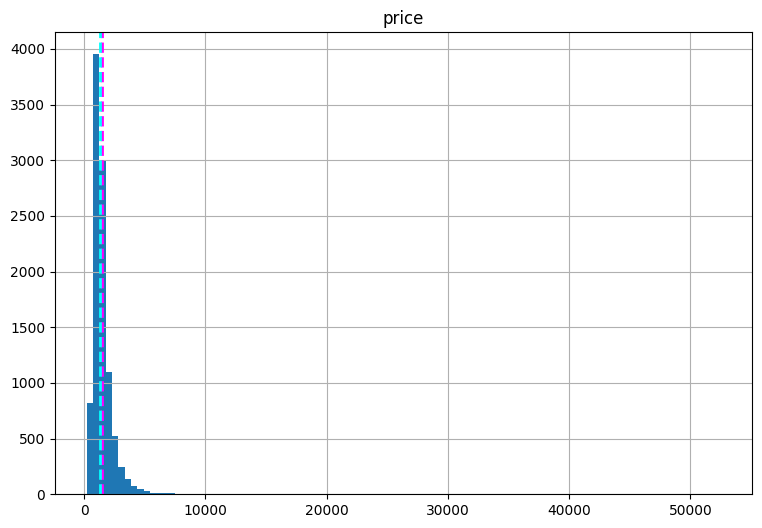

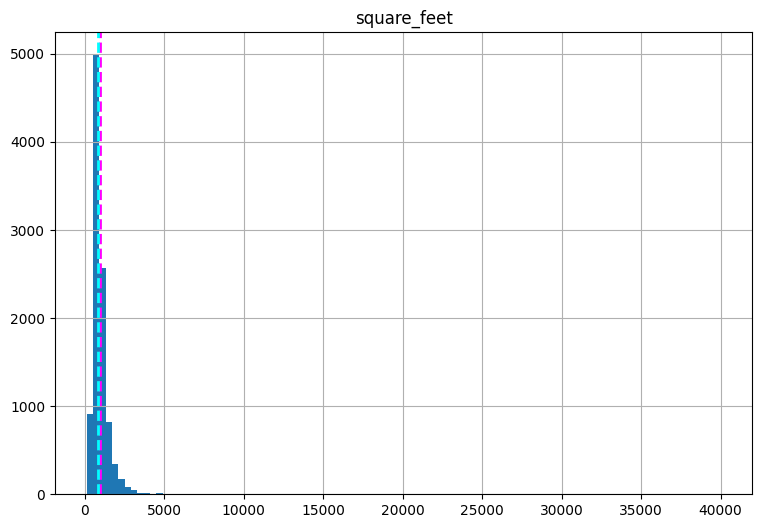

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_histogram(rent, col):
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    feature = rent[col]
    feature.hist(bins=100, ax = ax)
    ax.axvline(feature.mean(), color='magenta', linestyle='dashed', linewidth=2)
    ax.axvline(feature.median(), color='cyan', linestyle='dashed', linewidth=2)
    ax.set_title(col)

numeric_features = ['price', 'square_feet']
for col in numeric_features:
    plot_histogram(rent, col)
plt.show()

In [22]:
(rent['has_photo'] != 'Yes').sum()

np.int64(9089)